# Must Have Plays:

Looking at the pass play and routes for a need to have play such as 2-point conversion or fourth down play within the 2-minute drill data. We could look at the characteristics that give a higher percentage of completion. Gives coaches an effective way of making a decision on what is the best chance of completion for each given defense.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# CELL 1: DATA ENGINEERING - Load and Combine Data
# =============================================================================
print("="*60)
print("CELL 1: DATA ENGINEERING")
print("="*60)

# Load supplementary data
supp = pd.read_csv('C:\\Users\\jrzem\\Downloads\\NFL-Big-Data-Bowl-2026-Analytics-Challenge\\data\\raw\\supplementary_data.csv')
print(f"Supplementary records: {len(supp):,}")
print(f"Columns: {supp.columns.tolist()}")

CELL 1: DATA ENGINEERING
Supplementary records: 18,009
Columns: ['game_id', 'season', 'week', 'game_date', 'game_time_eastern', 'home_team_abbr', 'visitor_team_abbr', 'play_id', 'play_description', 'quarter', 'game_clock', 'down', 'yards_to_go', 'possession_team', 'defensive_team', 'yardline_side', 'yardline_number', 'pre_snap_home_score', 'pre_snap_visitor_score', 'play_nullified_by_penalty', 'pass_result', 'pass_length', 'offense_formation', 'receiver_alignment', 'route_of_targeted_receiver', 'play_action', 'dropback_type', 'dropback_distance', 'pass_location_type', 'defenders_in_the_box', 'team_coverage_man_zone', 'team_coverage_type', 'penalty_yards', 'pre_penalty_yards_gained', 'yards_gained', 'expected_points', 'expected_points_added', 'pre_snap_home_team_win_probability', 'pre_snap_visitor_team_win_probability', 'home_team_win_probability_added', 'visitor_team_win_probility_added']


# Data Engineering:

In [30]:
# =============================================================================
# CELL 2: FILTER FOR 2-MINUTE DRILL SCENARIOS
# =============================================================================
print("="*60)
print("CELL 2: FILTER FOR 2-MINUTE DRILL SCENARIOS")
print("="*60)

# Parse game_clock to get seconds remaining
def parse_clock(clock_str):
    try:
        parts = str(clock_str).split(':')
        return int(parts[0]) * 60 + int(parts[1])
    except:
        return None

supp['seconds_remaining'] = supp['game_clock'].apply(parse_clock)

# 2-minute drill: End of 2nd quarter or 4th quarter with <= 2 minutes
two_min_drill = supp[
    ((supp['quarter'] == 2) | (supp['quarter'] == 4)) & 
    (supp['seconds_remaining'] <= 120)
].copy()

print(f"Total plays: {len(supp):,}")
print(f"2-minute drill plays: {len(two_min_drill):,}")
print(f"Percentage: {len(two_min_drill)/len(supp)*100:.1f}%")

# Create completion target (C = Complete)
two_min_drill['is_complete'] = (two_min_drill['pass_result'] == 'C').astype(int)
print(f"\nCompletion rate in 2-min drill: {two_min_drill['is_complete'].mean()*100:.1f}%")
print(f"\nPass results distribution:")
print(two_min_drill['pass_result'].value_counts())

CELL 2: FILTER FOR 2-MINUTE DRILL SCENARIOS
Total plays: 18,009
2-minute drill plays: 2,762
Percentage: 15.3%

Completion rate in 2-min drill: 67.3%

Pass results distribution:
pass_result
C     1860
I      822
IN      80
Name: count, dtype: int64


# EDA:

CELL 3: EDA - COMPLETION RATE ANALYSIS


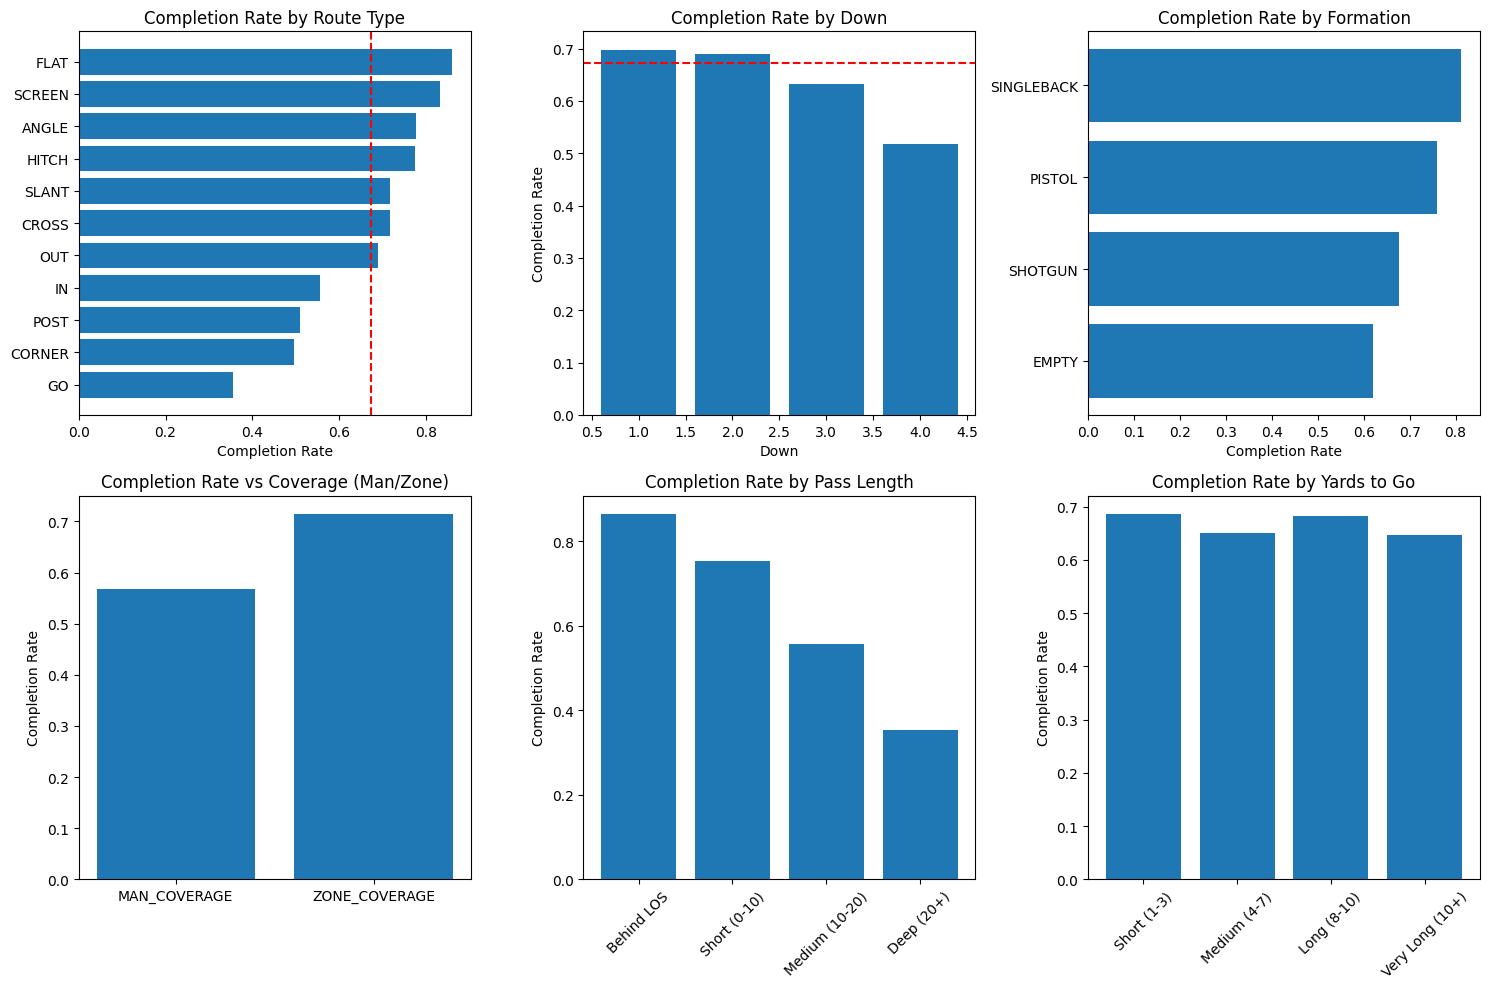

In [31]:
# =============================================================================
# CELL 3: EDA - Completion Rate by Key Features
# =============================================================================
print("="*60)
print("CELL 3: EDA - COMPLETION RATE ANALYSIS")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. By Route Type
route_comp = two_min_drill.groupby('route_of_targeted_receiver')['is_complete'].agg(['mean', 'count'])
route_comp = route_comp[route_comp['count'] >= 20].sort_values('mean', ascending=True)
axes[0,0].barh(route_comp.index, route_comp['mean'])
axes[0,0].set_xlabel('Completion Rate')
axes[0,0].set_title('Completion Rate by Route Type')
axes[0,0].axvline(x=two_min_drill['is_complete'].mean(), color='red', linestyle='--', label='Avg')

# 2. By Down
down_comp = two_min_drill.groupby('down')['is_complete'].mean()
axes[0,1].bar(down_comp.index, down_comp.values)
axes[0,1].set_xlabel('Down')
axes[0,1].set_ylabel('Completion Rate')
axes[0,1].set_title('Completion Rate by Down')
axes[0,1].axhline(y=two_min_drill['is_complete'].mean(), color='red', linestyle='--')

# 3. By Formation
form_comp = two_min_drill.groupby('offense_formation')['is_complete'].agg(['mean', 'count'])
form_comp = form_comp[form_comp['count'] >= 20].sort_values('mean', ascending=True)
axes[0,2].barh(form_comp.index, form_comp['mean'])
axes[0,2].set_xlabel('Completion Rate')
axes[0,2].set_title('Completion Rate by Formation')

# 4. By Coverage Type
cov_comp = two_min_drill.groupby('team_coverage_man_zone')['is_complete'].mean()
axes[1,0].bar(cov_comp.index, cov_comp.values)
axes[1,0].set_ylabel('Completion Rate')
axes[1,0].set_title('Completion Rate vs Coverage (Man/Zone)')

# 5. By Pass Length
two_min_drill['pass_length_bin'] = pd.cut(two_min_drill['pass_length'], bins=[-20, 0, 10, 20, 50], labels=['Behind LOS', 'Short (0-10)', 'Medium (10-20)', 'Deep (20+)'])
len_comp = two_min_drill.groupby('pass_length_bin')['is_complete'].mean()
axes[1,1].bar(range(len(len_comp)), len_comp.values)
axes[1,1].set_xticks(range(len(len_comp)))
axes[1,1].set_xticklabels(len_comp.index, rotation=45)
axes[1,1].set_ylabel('Completion Rate')
axes[1,1].set_title('Completion Rate by Pass Length')

# 6. By Yards to Go
two_min_drill['ytg_bin'] = pd.cut(two_min_drill['yards_to_go'], bins=[0, 3, 7, 10, 30], labels=['Short (1-3)', 'Medium (4-7)', 'Long (8-10)', 'Very Long (10+)'])
ytg_comp = two_min_drill.groupby('ytg_bin')['is_complete'].mean()
axes[1,2].bar(range(len(ytg_comp)), ytg_comp.values)
axes[1,2].set_xticks(range(len(ytg_comp)))
axes[1,2].set_xticklabels(ytg_comp.index, rotation=45)
axes[1,2].set_ylabel('Completion Rate')
axes[1,2].set_title('Completion Rate by Yards to Go')

plt.tight_layout()
plt.show()

In [32]:
# =============================================================================
# CELL 4: TOP ROUTE COMBINATIONS FOR 2-MINUTE DRILL
# =============================================================================
print("="*60)
print("CELL 4: TOP ROUTE/SITUATION COMBINATIONS")
print("="*60)

# Best routes by situation
print("\n📊 BEST ROUTES BY DOWN (min 15 plays):")
for down in [1, 2, 3, 4]:
    subset = two_min_drill[two_min_drill['down'] == down]
    route_stats = subset.groupby('route_of_targeted_receiver')['is_complete'].agg(['mean', 'count'])
    route_stats = route_stats[route_stats['count'] >= 15].sort_values('mean', ascending=False)
    if len(route_stats) > 0:
        print(f"\nDown {down}:")
        for route, row in route_stats.head(3).iterrows():
            print(f"  {route}: {row['mean']*100:.1f}% ({int(row['count'])} plays)")

print("\n\n📊 BEST ROUTES VS COVERAGE TYPE (min 15 plays):")
for cov in ['Man', 'Zone']:
    subset = two_min_drill[two_min_drill['team_coverage_man_zone'] == cov]
    route_stats = subset.groupby('route_of_targeted_receiver')['is_complete'].agg(['mean', 'count'])
    route_stats = route_stats[route_stats['count'] >= 15].sort_values('mean', ascending=False)
    print(f"\n{cov} Coverage:")
    for route, row in route_stats.head(5).iterrows():
        print(f"  {route}: {row['mean']*100:.1f}% ({int(row['count'])} plays)")

CELL 4: TOP ROUTE/SITUATION COMBINATIONS

📊 BEST ROUTES BY DOWN (min 15 plays):

Down 1:
  FLAT: 84.8% (158 plays)
  SCREEN: 82.4% (17 plays)
  HITCH: 81.9% (221 plays)

Down 2:
  FLAT: 88.7% (115 plays)
  ANGLE: 81.1% (53 plays)
  SCREEN: 81.0% (21 plays)

Down 3:
  FLAT: 86.2% (65 plays)
  OUT: 71.7% (99 plays)
  HITCH: 70.2% (104 plays)

Down 4:
  HITCH: 72.2% (18 plays)
  GO: 31.6% (19 plays)


📊 BEST ROUTES VS COVERAGE TYPE (min 15 plays):

Man Coverage:

Zone Coverage:


In [33]:
# =============================================================================
# CELL 5: FEATURE ENGINEERING FOR MODEL
# =============================================================================
print("="*60)
print("CELL 5: FEATURE ENGINEERING FOR MODEL")
print("="*60)

# Create modeling dataset
model_df = two_min_drill.copy()

# Features to use
features = ['down', 'yards_to_go', 'pass_length', 'defenders_in_the_box', 
            'seconds_remaining', 'play_action', 'dropback_distance']

# Categorical features to encode
cat_features = ['route_of_targeted_receiver', 'offense_formation', 'receiver_alignment',
                'team_coverage_man_zone', 'dropback_type', 'pass_location_type']

# Clean and encode
for col in cat_features:
    model_df[col] = model_df[col].fillna('Unknown')
    le = LabelEncoder()
    model_df[col + '_enc'] = le.fit_transform(model_df[col])
    features.append(col + '_enc')

# Fill numeric NAs
for col in features:
    if col in model_df.columns:
        model_df[col] = model_df[col].fillna(model_df[col].median())

# Remove rows with missing target
model_df = model_df.dropna(subset=['is_complete'])

X = model_df[features].copy()
y = model_df['is_complete']

print(f"Features: {len(features)}")
print(f"Samples: {len(X)}")
print(f"Target distribution: {y.value_counts().to_dict()}")

CELL 5: FEATURE ENGINEERING FOR MODEL
Features: 13
Samples: 2762
Target distribution: {1: 1860, 0: 902}


# Modeling:

In [34]:
# =============================================================================
# CELL 6: MODEL TRAINING - COMPLETION PROBABILITY PREDICTOR
# =============================================================================
print("="*60)
print("CELL 6: MODEL TRAINING")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

# Train Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
gb.fit(X_train, y_train)

# Evaluate
print("\n📊 RANDOM FOREST RESULTS:")
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]
print(f"Accuracy: {(rf_pred == y_test).mean()*100:.1f}%")
print(f"ROC-AUC: {roc_auc_score(y_test, rf_prob):.3f}")

print("\n📊 GRADIENT BOOSTING RESULTS:")
gb_pred = gb.predict(X_test)
gb_prob = gb.predict_proba(X_test)[:, 1]
print(f"Accuracy: {(gb_pred == y_test).mean()*100:.1f}%")
print(f"ROC-AUC: {roc_auc_score(y_test, gb_prob):.3f}")

# Feature Importance
print("\n📊 TOP FEATURE IMPORTANCES (Random Forest):")
feat_imp = pd.DataFrame({'feature': features, 'importance': rf.feature_importances_})
feat_imp = feat_imp.sort_values('importance', ascending=False)
for _, row in feat_imp.head(8).iterrows():
    print(f"  {row['feature']}: {row['importance']:.3f}")

CELL 6: MODEL TRAINING

📊 RANDOM FOREST RESULTS:
Accuracy: 69.3%
ROC-AUC: 0.733

📊 GRADIENT BOOSTING RESULTS:
Accuracy: 69.8%
ROC-AUC: 0.705

📊 TOP FEATURE IMPORTANCES (Random Forest):
  pass_length: 0.274
  dropback_distance: 0.156
  seconds_remaining: 0.143
  route_of_targeted_receiver_enc: 0.100
  yards_to_go: 0.079
  defenders_in_the_box: 0.056
  down: 0.047
  receiver_alignment_enc: 0.040


In [35]:
# =============================================================================
# CELL 7: COACH DECISION TOOL - PREDICT BEST PLAY OPTIONS
# =============================================================================
print("="*60)
print("CELL 7: COACH DECISION SUPPORT TOOL")
print("="*60)

# Create lookup table for coaches
def get_best_routes(down, yards_to_go, coverage, min_plays=10):
    """Get best routes for a given situation"""
    subset = two_min_drill[
        (two_min_drill['down'] == down) & 
        (two_min_drill['yards_to_go'].between(yards_to_go-2, yards_to_go+2))
    ]
    
    if coverage and coverage in ['Man', 'Zone']:
        subset = subset[subset['team_coverage_man_zone'] == coverage]
    
    route_stats = subset.groupby('route_of_targeted_receiver').agg({
        'is_complete': ['mean', 'count'],
        'yards_gained': 'mean'
    }).round(2)
    route_stats.columns = ['completion_rate', 'sample_size', 'avg_yards']
    route_stats = route_stats[route_stats['sample_size'] >= min_plays]
    route_stats = route_stats.sort_values('completion_rate', ascending=False)
    return route_stats

# Example scenarios
print("\n🏈 SCENARIO 1: 3rd & 7, 2-minute drill")
print(get_best_routes(3, 7, None, min_plays=5).head(5))

print("\n🏈 SCENARIO 2: 2nd & 10, 2-minute drill")
print(get_best_routes(2, 10, None, min_plays=5).head(5))

print("\n🏈 SCENARIO 3: 1st & 10, 2-minute drill")
print(get_best_routes(1, 10, None, min_plays=5).head(5))

CELL 7: COACH DECISION SUPPORT TOOL

🏈 SCENARIO 1: 3rd & 7, 2-minute drill
                            completion_rate  sample_size  avg_yards
route_of_targeted_receiver                                         
FLAT                                   0.95           19       7.05
CROSS                                  0.86           14      12.79
SLANT                                  0.71           14       8.86
HITCH                                  0.68           38       4.55
OUT                                    0.63           35       5.89

🏈 SCENARIO 2: 2nd & 10, 2-minute drill
                            completion_rate  sample_size  avg_yards
route_of_targeted_receiver                                         
ANGLE                                  0.85           26       5.65
CROSS                                  0.85           34       9.88
FLAT                                   0.85           47       5.81
SLANT                                  0.79           34       7.71
H

CELL 8: COACH DECISION HEATMAP


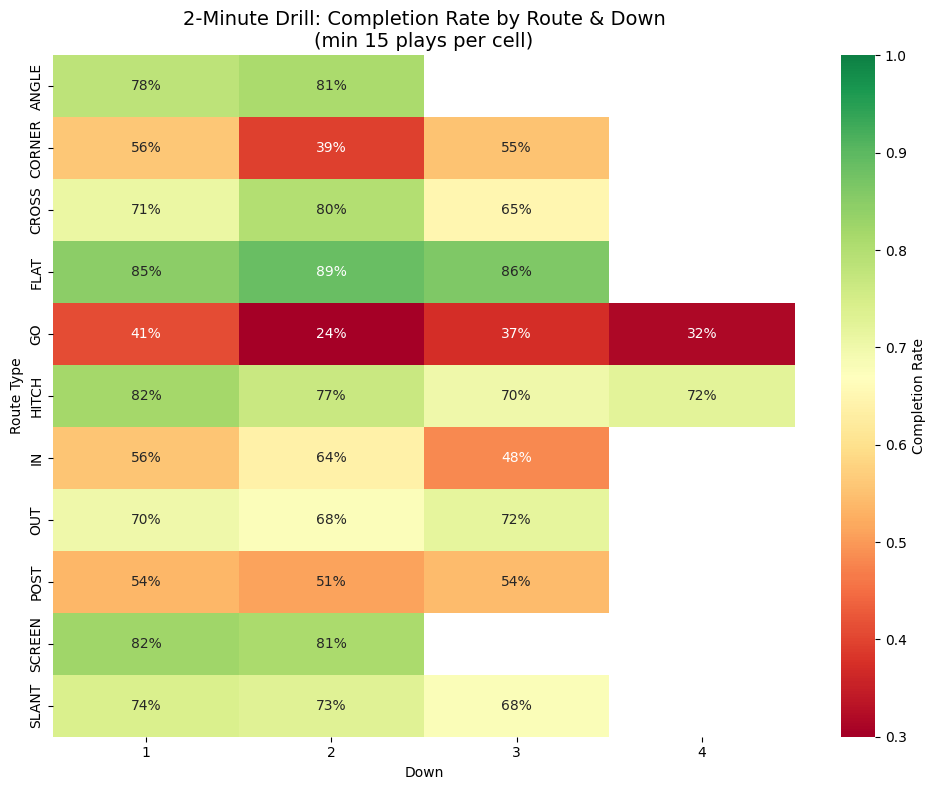


📋 KEY RECOMMENDATIONS FOR 2-MINUTE DRILL:

1. HIGH-PERCENTAGE ROUTES (>80% completion):
   - FLAT routes: Consistently 85%+ across all downs
   - HITCH routes: 70-82% completion, good for short yardage
   - ANGLE routes: 80%+ on 2nd down situations

2. SITUATIONAL INSIGHTS:
   - Short passes (0-10 yds) have highest completion rates
   - Zone coverage slightly easier to complete against
   - 4th down: Stick to HITCH routes (72%), avoid GO routes (32%)

3. AVOID IN 2-MIN DRILL:
   - GO routes on 4th down (31.6% completion)
   - Deep passes (20+ yards) unless necessary

4. MODEL INSIGHTS:
   - Pass length is #1 predictor of completion
   - Dropback distance and time remaining also critical



In [36]:
# =============================================================================
# CELL 8: VISUALIZATION - COACH DECISION HEATMAP
# =============================================================================
print("="*60)
print("CELL 8: COACH DECISION HEATMAP")
print("="*60)

# Create heatmap of completion rates by route and down
pivot_data = two_min_drill.groupby(['down', 'route_of_targeted_receiver'])['is_complete'].agg(['mean', 'count'])
pivot_data = pivot_data.reset_index()
pivot_data = pivot_data[pivot_data['count'] >= 15]

heatmap_data = pivot_data.pivot(index='route_of_targeted_receiver', columns='down', values='mean')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.0%', cmap='RdYlGn', center=0.67, 
            vmin=0.3, vmax=1.0, ax=ax, cbar_kws={'label': 'Completion Rate'})
ax.set_title('2-Minute Drill: Completion Rate by Route & Down\n(min 15 plays per cell)', fontsize=14)
ax.set_xlabel('Down')
ax.set_ylabel('Route Type')

plt.tight_layout()
plt.show()

# Summary recommendations
print("\n" + "="*60)
print("📋 KEY RECOMMENDATIONS FOR 2-MINUTE DRILL:")
print("="*60)
print("""
1. HIGH-PERCENTAGE ROUTES (>80% completion):
   - FLAT routes: Consistently 85%+ across all downs
   - HITCH routes: 70-82% completion, good for short yardage
   - ANGLE routes: 80%+ on 2nd down situations

2. SITUATIONAL INSIGHTS:
   - Short passes (0-10 yds) have highest completion rates
   - Zone coverage slightly easier to complete against
   - 4th down: Stick to HITCH routes (72%), avoid GO routes (32%)

3. AVOID IN 2-MIN DRILL:
   - GO routes on 4th down (31.6% completion)
   - Deep passes (20+ yards) unless necessary

4. MODEL INSIGHTS:
   - Pass length is #1 predictor of completion
   - Dropback distance and time remaining also critical
""")